# Lab 1. Compliance Functions, Creep, and Recovery

A creep experiment applies an approximately constant stress and measures the strain that develops with time. A recovery experiment then removes the stress and measures which part of the deformation is recovered. Together, these protocols distinguish instantaneous elasticity, delayed elasticity, and viscous flow.

## Learning outcomes

After completing this notebook, you should be able to:

- derive creep responses from spring--dashpot constitutive equations;
- distinguish instantaneous elastic strain, delayed elastic strain, and viscous flow;
- interpret retardation time as a material timescale;
- generate forward responses from candidate constitutive models;
- fit compliance data and quantify parameter uncertainty;
- compare model classes using residuals and an information criterion;
- predict creep recovery under unloading.


## 1.1 State variables and loading protocol

We work in uniaxial, small-strain, linear viscoelasticity. Stress is $\sigma(t)$ in MPa and strain is $\epsilon(t)$, which is dimensionless. A step-stress experiment imposes

$$
\sigma(t)=\sigma_0 H(t),
$$

where $H(t)$ is the Heaviside step function. The compliance function is defined by

$$
J(t)=\frac{\epsilon(t)}{\sigma_0}, \qquad t>0.
$$

Thus $J(t)$ has units MPa$^{-1}$. In an ideal step experiment, the loading protocol is the input and strain is the measured output.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

plt.rcParams.update({"figure.figsize": (7.0, 4.4), "axes.grid": True})


## 1.2 Mechanical Elements and Constitutive Models

We consider one-dimensional, small-strain, linear viscoelastic behavior. The mechanical variables are:

- $\sigma(t)$: stress;
- $\epsilon(t)$: strain;
- $E$: elastic modulus;
- $\eta$: viscosity;
- $\dot{\epsilon}(t)=\mathrm d\epsilon/\mathrm dt$: strain rate.

If

$$
D=\frac{\mathrm d}{\mathrm dt}
$$

denotes the time-derivative operator, a linear constitutive model can be written as

$$
\mathcal L_\sigma(D)\sigma(t)
=
\mathcal L_\epsilon(D)\epsilon(t).
$$

The operators $\mathcal L_\sigma(D)$ and $\mathcal L_\epsilon(D)$ define the material model. The loading history and initial conditions determine the resulting stress and strain histories.

### Spring

An ideal spring represents purely elastic deformation:

$$
\sigma(t)=E\epsilon(t).
$$

Therefore,

$$
\epsilon(t)=\frac{\sigma(t)}{E}.
$$

Under a step stress,

$$
\sigma(t)=\sigma_0H(t),
$$

the strain jumps instantaneously to

$$
\epsilon(t)=\frac{\sigma_0}{E}.
$$

The creep compliance is

$$
\boxed{
J_{\mathrm{spring}}(t)=\frac{1}{E}
}.
$$

The spring stores mechanical energy and completely recovers its deformation when the stress is removed. It has no delayed response and no permanent deformation.

### Dashpot

An ideal dashpot represents purely viscous flow:

$$
\sigma(t)=\eta\dot{\epsilon}(t).
$$

Therefore,

$$
\dot{\epsilon}(t)=\frac{\sigma(t)}{\eta}.
$$

Under a constant step stress $\sigma_0$,

$$
\dot{\epsilon}(t)=\frac{\sigma_0}{\eta},
$$

so the strain increases linearly:

$$
\epsilon(t)=\frac{\sigma_0}{\eta}t,
$$

assuming $\epsilon(0)=0$. The creep compliance is

$$
\boxed{
J_{\mathrm{dashpot}}(t)=\frac{t}{\eta}
}.
$$

The dashpot does not deform instantaneously. It flows continuously while stress is applied, and the accumulated deformation remains after unloading.

### Kelvin--Voigt Model

The Kelvin--Voigt model consists of a spring and dashpot connected in parallel. Both elements experience the same strain,

$$
\epsilon_{\mathrm{spring}}
=
\epsilon_{\mathrm{dashpot}}
=
\epsilon,
$$

while their stresses add:

$$
\sigma
=
\sigma_{\mathrm{spring}}
+
\sigma_{\mathrm{dashpot}}.
$$

Its constitutive equation is

$$
\boxed{
\sigma(t)
=
E\epsilon(t)
+
\eta\dot{\epsilon}(t)
}.
$$

Under a step stress $\sigma_0$,

$$
\eta\dot{\epsilon}+E\epsilon=\sigma_0.
$$

With $\epsilon(0)=0$, the strain is

$$
\epsilon(t)
=
\frac{\sigma_0}{E}
\left(
1-e^{-t/\tau_c}
\right),
$$

where

$$
\boxed{
\tau_c=\frac{\eta}{E}
}
$$

is the retardation time. The creep compliance is

$$
\boxed{
J_{\mathrm{KV}}(t)
=
\frac{1}{E}
\left(
1-e^{-t/\tau_c}
\right)
}.
$$

The Kelvin--Voigt model has no instantaneous strain because the dashpot initially resists sudden deformation. The strain gradually approaches the equilibrium value $\sigma_0/E$. When the stress is removed, the deformation gradually and completely recovers. It therefore represents a viscoelastic solid.

### Maxwell Model

The Maxwell model consists of a spring and dashpot connected in series. Both elements carry the same stress,

$$
\sigma_{\mathrm{spring}}
=
\sigma_{\mathrm{dashpot}}
=
\sigma,
$$

while their strains add:

$$
\epsilon
=
\epsilon_{\mathrm{spring}}
+
\epsilon_{\mathrm{dashpot}}.
$$

For the spring,

$$
\dot{\epsilon}_{\mathrm{spring}}
=
\frac{\dot{\sigma}}{E},
$$

and for the dashpot,

$$
\dot{\epsilon}_{\mathrm{dashpot}}
=
\frac{\sigma}{\eta}.
$$

The Maxwell constitutive equation is therefore

$$
\boxed{
\dot{\epsilon}(t)
=
\frac{\dot{\sigma}(t)}{E}
+
\frac{\sigma(t)}{\eta}
}.
$$

Under a step stress $\sigma_0$, the spring produces an instantaneous strain

$$
\epsilon_{\mathrm{spring}}
=
\frac{\sigma_0}{E},
$$

while the dashpot produces a linearly increasing strain

$$
\epsilon_{\mathrm{dashpot}}
=
\frac{\sigma_0}{\eta}t.
$$

The total strain is

$$
\epsilon(t)
=
\frac{\sigma_0}{E}
+
\frac{\sigma_0}{\eta}t,
$$

and the creep compliance is

$$
\boxed{
J_{\mathrm{Maxwell}}(t)
=
\frac{1}{E}
+
\frac{t}{\eta}
}.
$$

When the stress is removed, the elastic strain $\,\sigma_0/E\,$ recovers instantaneously, but the viscous strain remains. The Maxwell model therefore represents a viscoelastic fluid.

### Comparison of the Four Models

| Model | Element arrangement | Step-stress compliance | Instantaneous strain | Long-time creep | Recovery |
| --- | --- | --- | --- | --- | --- |
| Spring | Single spring | $J(t)=1/E$ | Yes | Bounded | Instantaneous and complete |
| Dashpot | Single dashpot | $J(t)=t/\eta$ | No | Unbounded | None |
| Kelvin--Voigt | Spring and dashpot in parallel | $J(t)=E^{-1}(1-e^{-t/\tau_c})$ | No | Bounded | Delayed and complete |
| Maxwell | Spring and dashpot in series | $J(t)=1/E+t/\eta$ | Yes | Unbounded | Elastic part only |

The four models are distinguished by three observable features:

1. whether strain appears instantaneously;
2. whether strain remains bounded under sustained stress;
3. whether deformation is recovered after unloading.

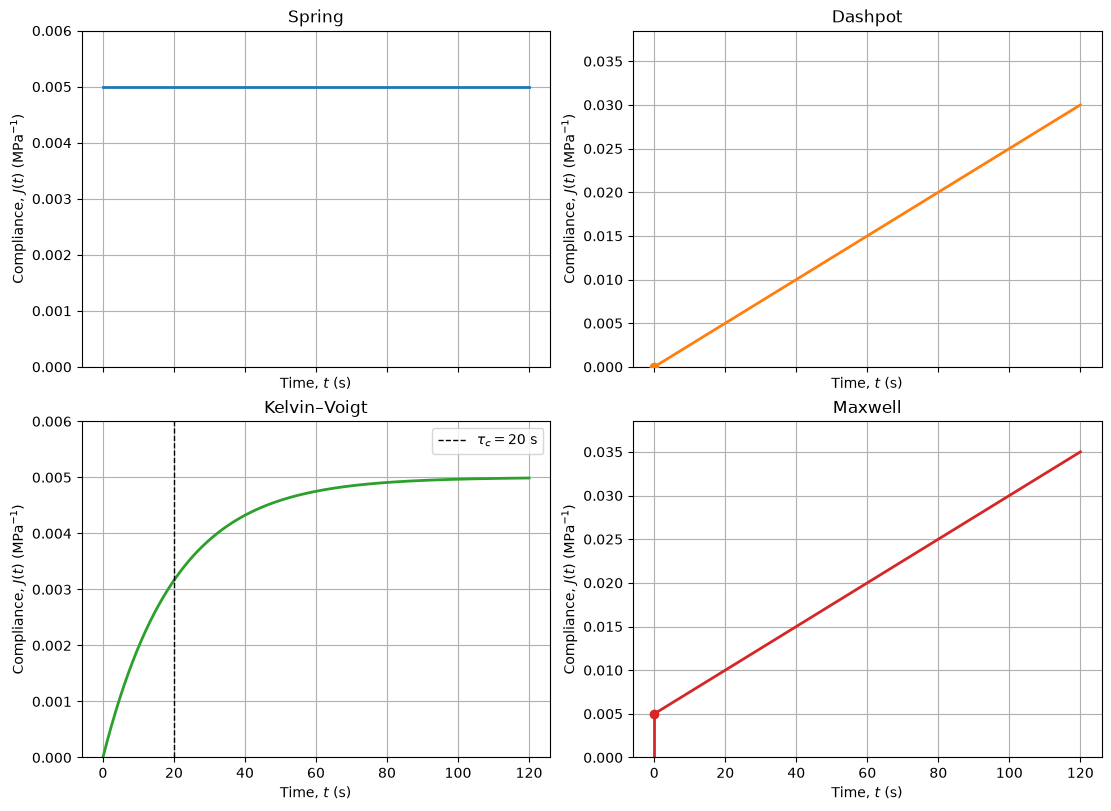

In [3]:
def J_spring(t, E):
    t = np.asarray(t, dtype=float)
    return np.full_like(t, 1.0 / E)

def J_dashpot(t, eta):
    return np.asarray(t, dtype=float) / eta

def J_kelvin_voigt(t, E, eta):
    t = np.asarray(t, dtype=float)
    tau_c = eta / E
    return (1.0 / E) * (1.0 - np.exp(-t / tau_c))

def J_maxwell(t, E, eta):
    t = np.asarray(t, dtype=float)
    return 1.0 / E + t / eta

t = np.linspace(0.0, 120.0, 500)
E = 200.0       # MPa
eta = 4000.0    # MPa s
tau = eta / E   # s

fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True,
                         constrained_layout=True)

axes[0, 0].plot(t, J_spring(t, E), color="C0", linewidth=2)
axes[0, 0].set_title("Spring")
axes[0, 0].set_ylim(0.0, 1.2 / E)

axes[0, 1].plot(t, J_dashpot(t, eta), color="C1", linewidth=2)
axes[0, 1].scatter(0.0, 0.0, color="C1", zorder=3)
axes[0, 1].set_title("Dashpot")

axes[1, 0].plot(t, J_kelvin_voigt(t, E, eta), color="C2", linewidth=2)
axes[1, 0].axvline(tau, color="black", linestyle="--", linewidth=1,
                   label=fr"$\tau_c={tau:.0f}\ \mathrm{{s}}$")
axes[1, 0].set_title("Kelvin–Voigt")
axes[1, 0].set_ylim(0.0, 1.2 / E)
axes[1, 0].legend()

axes[1, 1].plot(t, J_maxwell(t, E, eta), color="C3", linewidth=2)
axes[1, 1].vlines(0.0, 0.0, 1.0 / E, color="C3", linewidth=2)
axes[1, 1].scatter(0.0, 1.0 / E, color="C3", zorder=3)
axes[1, 1].set_title("Maxwell")

flow_limit = 1.1 * J_maxwell(t[-1], E, eta)
axes[0, 1].set_ylim(0.0, flow_limit)
axes[1, 1].set_ylim(0.0, flow_limit)

for ax in axes.flat:
    ax.set_xlabel(r"Time, $t$ (s)")
    ax.set_ylabel(r"Compliance, $J(t)$ (MPa$^{-1}$)")
    ax.grid(True)

plt.show()


The four curves encode different mechanisms:

- a spring responds immediately and then stops deforming;
- a dashpot flows indefinitely without instantaneous strain;
- a Kelvin--Voigt solid approaches a finite strain gradually;
- a Maxwell fluid has an instantaneous elastic strain followed by unbounded flow.

The dashpot and Maxwell curves have the same slope $1/\eta$. Their difference is the Maxwell model's instantaneous intercept $1/E$. Identical vertical scales on those two panels make this difference visible.

**Prediction checkpoint.** Before changing any parameters, predict what increasing $E$ and increasing $\eta$ will do to each curve. Then test the prediction numerically. These limiting behaviors are often more diagnostic than the detailed curve shape.


## 1.3 Standard linear solid in compliance form

A standard linear solid can represent both instantaneous and delayed elastic deformation without permanent flow. Its creep compliance can be parameterized as

$$
J_{\mathrm{SLS}}(t)
=J_0+(J_\infty-J_0)\left(1-e^{-t/\tau_c}\right),
$$

where:

- $J_0=J(0^+)$ is the instantaneous compliance;
- $J_\infty=J(t\rightarrow\infty)$ is the equilibrium compliance;
- $\tau_c$ is the creep retardation time.

A passive viscoelastic solid requires $0<J_0<J_\infty$ and $\tau_c>0$. The corresponding instantaneous and equilibrium moduli are $E_0=1/J_0$ and $E_\infty=1/J_\infty$.


In [4]:
def J_sls(t, J0, Jinf, tau_c):
    t = np.asarray(t, dtype=float)
    return J0 + (Jinf - J0) * (1.0 - np.exp(-t / tau_c))

parameters = {
    "instantaneous compliance J0": 0.004,
    "equilibrium compliance Jinf": 0.012,
    "retardation time tau_c": 25.0,
}
J0, Jinf, tau_c = parameters.values()

print(f"Instantaneous modulus E0 = {1/J0:.1f} MPa")
print(f"Equilibrium modulus Einf = {1/Jinf:.1f} MPa")
print(f"At t = tau_c, the delayed compliance is {100*(1-np.exp(-1)):.1f}% complete.")


Instantaneous modulus E0 = 250.0 MPa
Equilibrium modulus Einf = 83.3 MPa
At t = tau_c, the delayed compliance is 63.2% complete.


## 1.4 Generate a synthetic creep experiment

The next cell deliberately retains the forward model and data-generation procedure. This makes the assumptions, parameter values, sampling schedule, and noise model auditable. The resulting dataset is instructional rather than experimental.

For an assessed version, one group can change the generation parameters and export the resulting data for another group to analyze. The analyzing group should receive the data but not the generating parameters.


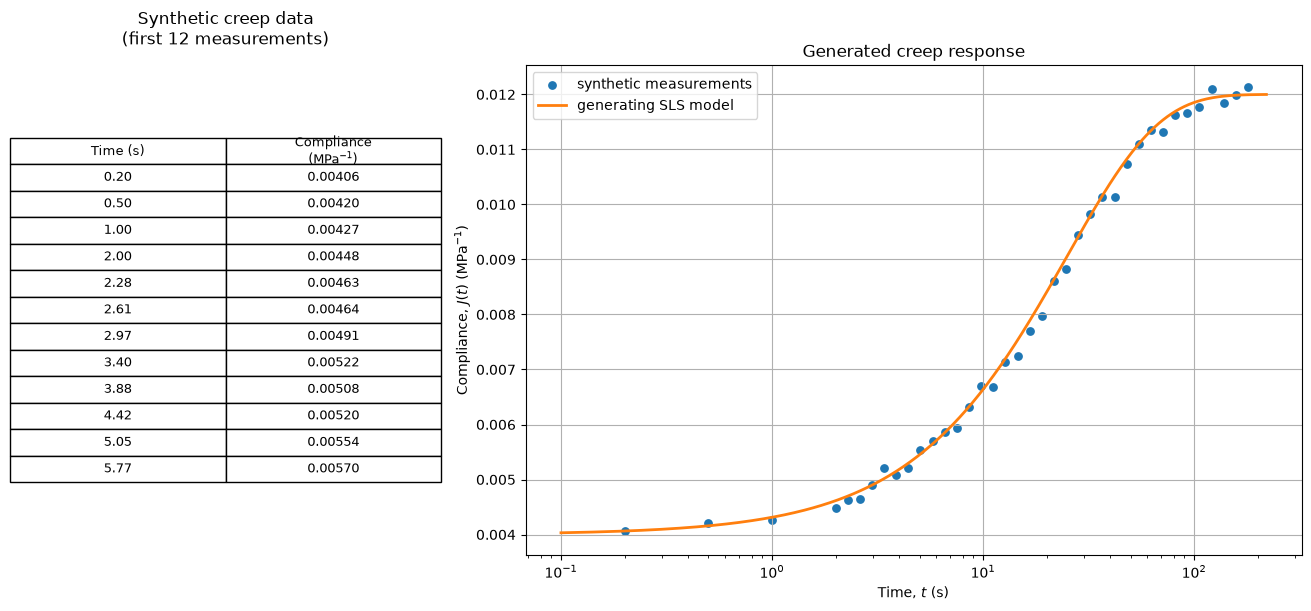

In [5]:
generation_parameters = {
    "J0": 0.004,       # MPa^-1
    "Jinf": 0.012,     # MPa^-1
    "tau_c": 25.0,     # s
    "noise_sd": 1.5e-4 # MPa^-1
}

rng = np.random.default_rng(7)
t_data = np.concatenate(([0.2, 0.5, 1.0], np.geomspace(2.0, 180.0, 35)))
J_true = J_sls(
    t_data,
    generation_parameters["J0"],
    generation_parameters["Jinf"],
    generation_parameters["tau_c"],
)
J_measured = J_true + rng.normal(
    0.0,
    generation_parameters["noise_sd"],
    size=t_data.size,
)

creep_data = pd.DataFrame({
    "Time (s)": t_data,
    "Compliance (MPa^-1)": J_measured,
})

fig, (ax_table, ax_plot) = plt.subplots(
    1, 2, figsize=(13, 6),
    gridspec_kw={"width_ratios": [1.0, 1.8]},
    constrained_layout=True,
)

table_data = creep_data.head(12).copy()
table_data["Time (s)"] = table_data["Time (s)"].map(lambda x: f"{x:.2f}")
table_data["Compliance (MPa^-1)"] = table_data["Compliance (MPa^-1)"].map(
    lambda x: f"{x:.5f}"
)
ax_table.axis("off")
table = ax_table.table(
    cellText=table_data.values,
    colLabels=["Time (s)", "Compliance\n(MPa$^{-1}$)"],
    cellLoc="center",
    colLoc="center",
    loc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.0, 1.5)
ax_table.set_title("Synthetic creep data\n(first 12 measurements)", pad=15)

t_preview = np.geomspace(0.1, 220.0, 500)
ax_plot.scatter(t_data, J_measured, s=28, label="synthetic measurements")
ax_plot.plot(t_preview, J_sls(t_preview, *list(generation_parameters.values())[:3]),
             color="C1", linewidth=2, label="generating SLS model")
ax_plot.set_xscale("log")
ax_plot.set_xlabel(r"Time, $t$ (s)")
ax_plot.set_ylabel(r"Compliance, $J(t)$ (MPa$^{-1}$)")
ax_plot.set_title("Generated creep response")
ax_plot.legend()
plt.show()


In [6]:
p0 = (0.003, 0.010, 20.0)
bounds = ([0.0, 0.0, 1e-6], [np.inf, np.inf, np.inf])
popt, pcov = curve_fit(J_sls, t_data, J_measured, p0=p0, bounds=bounds)
perr = np.sqrt(np.diag(pcov))
J_fit = J_sls(t_data, *popt)
residual = J_measured - J_fit

fit_table = pd.DataFrame({
    "parameter": ["J0 (MPa^-1)", "Jinf (MPa^-1)", "tau_c (s)"],
    "estimate": popt,
    "standard_error": perr,
})
fit_table


,parameter,estimate,standard_error
0,J0 (MPa^-1),0.004018,0.000044
1,Jinf (MPa^-1),0.011992,0.000049
2,tau_c (s),26.109272,0.541302


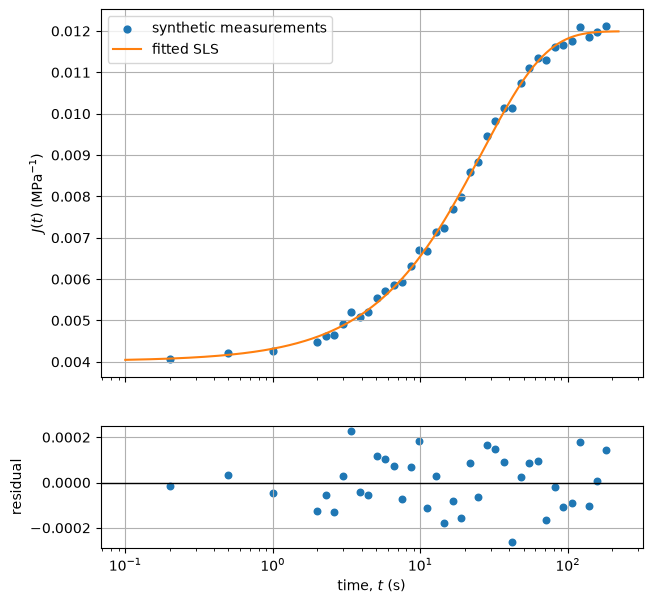

RMSE = 1.166e-04 MPa^-1
Fitted E0 = 248.9 MPa
Fitted Einf = 83.4 MPa


In [7]:
t_plot = np.geomspace(0.1, 220.0, 500)
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(7, 7), sharex=True,
                                gridspec_kw={"height_ratios": [3, 1]})
ax0.scatter(t_data, J_measured, s=24, label="synthetic measurements")
ax0.plot(t_plot, J_sls(t_plot, *popt), color="C1", label="fitted SLS")
ax0.set_xscale("log")
ax0.set_ylabel("$J(t)$ (MPa$^{-1}$)")
ax0.legend()

ax1.axhline(0.0, color="black", linewidth=1)
ax1.scatter(t_data, residual, s=22)
ax1.set_xscale("log")
ax1.set(xlabel="time, $t$ (s)", ylabel="residual")
plt.show()

rmse = np.sqrt(np.mean(residual**2))
print(f"RMSE = {rmse:.3e} MPa^-1")
print(f"Fitted E0 = {1/popt[0]:.1f} MPa")
print(f"Fitted Einf = {1/popt[1]:.1f} MPa")


## 1.5 Compare candidate model classes

A fit is meaningful only relative to plausible alternatives. Fit the spring, dashpot, Kelvin--Voigt, Maxwell, and standard-linear-solid models to the same measurements. For each model, calculate

$$
\mathrm{RMSE}=\sqrt{\frac{1}{n}\sum_{j=1}^{n}r_j^2},
$$

and the Gaussian least-squares Akaike information criterion

$$
\mathrm{AIC}=n\ln\left(\frac{\mathrm{RSS}}{n}\right)+2k,
$$

where $r_j$ is a residual, $\mathrm{RSS}=\sum_jr_j^2$, and $k$ is the number of fitted parameters. Only AIC differences among models fitted to the same observations are interpreted here.

The SLS comparison is parameterized using $\Delta J=J_\infty-J_0>0$ so that the fitted model remains physically ordered.


In [8]:
def J_sls_ordered(t, J0, delta_J, tau_c):
    return J_sls(t, J0, J0 + delta_J, tau_c)

candidate_specs = {
    "Spring": (J_spring, (150.0,), ([1e-9], [np.inf])),
    "Dashpot": (J_dashpot, (10000.0,), ([1e-9], [np.inf])),
    "Kelvin–Voigt": (
        J_kelvin_voigt,
        (100.0, 3000.0),
        ([1e-9, 1e-9], [np.inf, np.inf]),
    ),
    "Maxwell": (
        J_maxwell,
        (200.0, 10000.0),
        ([1e-9, 1e-9], [np.inf, np.inf]),
    ),
    "Standard linear solid": (
        J_sls_ordered,
        (0.003, 0.008, 20.0),
        ([1e-9, 1e-9, 1e-9], [np.inf, np.inf, np.inf]),
    ),
}

model_fits = {}
rows = []
n = t_data.size

for name, (model, initial_guess, model_bounds) in candidate_specs.items():
    parameters_fit, covariance = curve_fit(
        model,
        t_data,
        J_measured,
        p0=initial_guess,
        bounds=model_bounds,
        maxfev=30000,
    )
    prediction = model(t_data, *parameters_fit)
    model_residual = J_measured - prediction
    rss = np.sum(model_residual**2)
    k = len(parameters_fit)
    model_fits[name] = {
        "model": model,
        "parameters": parameters_fit,
        "residual": model_residual,
    }
    rows.append({
        "model": name,
        "parameters": k,
        "RMSE_MPa_inv": np.sqrt(rss / n),
        "AIC": n * np.log(rss / n) + 2 * k,
    })

comparison = pd.DataFrame(rows).sort_values("AIC").reset_index(drop=True)
comparison["delta_AIC"] = comparison["AIC"] - comparison["AIC"].min()
comparison


,model,parameters,RMSE_MPa_inv,AIC,delta_AIC
0,Standard linear solid,3,0.000117,-682.331466,0.000000
1,Kelvin–Voigt,2,0.001488,-490.770391,191.561075
2,Maxwell,2,0.001490,-490.707749,191.623717
3,Spring,1,0.002811,-444.432852,237.898614
4,Dashpot,1,0.004978,-401.010707,281.320759


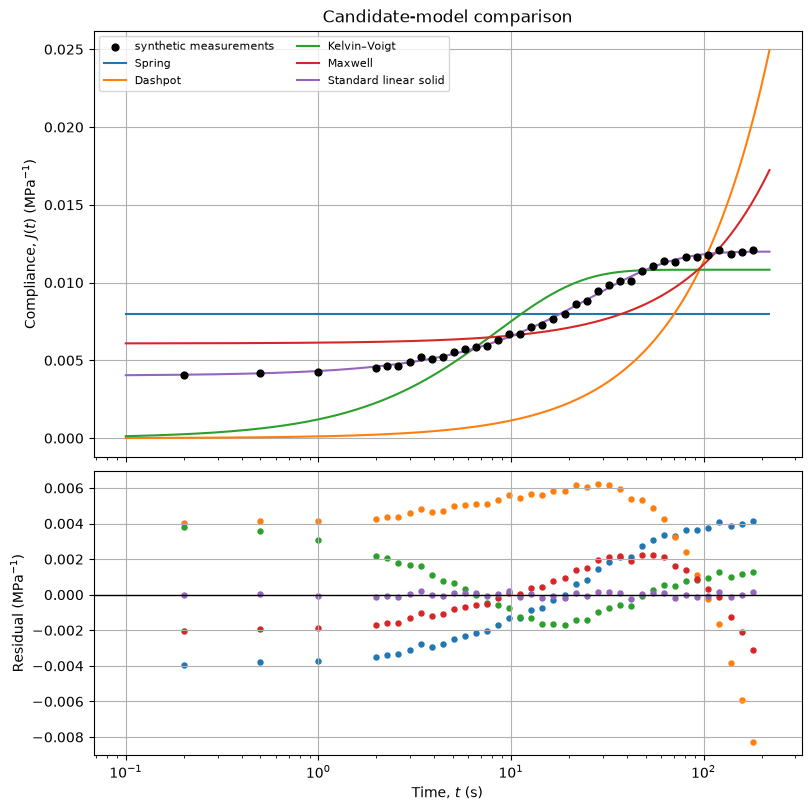

In [9]:
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(8, 8), sharex=True,
                                gridspec_kw={"height_ratios": [3, 2]},
                                constrained_layout=True)

ax0.scatter(t_data, J_measured, color="black", s=24,
            label="synthetic measurements", zorder=5)

for name, result in model_fits.items():
    model = result["model"]
    parameters_fit = result["parameters"]
    ax0.plot(t_plot, model(t_plot, *parameters_fit), label=name)
    ax1.scatter(t_data, result["residual"], s=13, label=name)

ax0.set_xscale("log")
ax0.set_ylabel(r"Compliance, $J(t)$ (MPa$^{-1}$)")
ax0.set_title("Candidate-model comparison")
ax0.legend(ncol=2, fontsize=8)

ax1.axhline(0.0, color="black", linewidth=1)
ax1.set_xscale("log")
ax1.set_xlabel(r"Time, $t$ (s)")
ax1.set_ylabel(r"Residual (MPa$^{-1}$)")
plt.show()


## 1.6 Predict creep recovery

Now replace the permanent step stress by a loading--unloading history,

$$
\sigma(t)=\sigma_0\left[H(t)-H(t-t_u)\right],
$$

where $t_u$ is the unloading time. Boltzmann superposition gives

$$
\epsilon(t)=\sigma_0J(t)-\sigma_0J(t-t_u)H(t-t_u).
$$

The unloading step probes whether the accumulated strain is instantaneous, delayed but recoverable, or permanent.


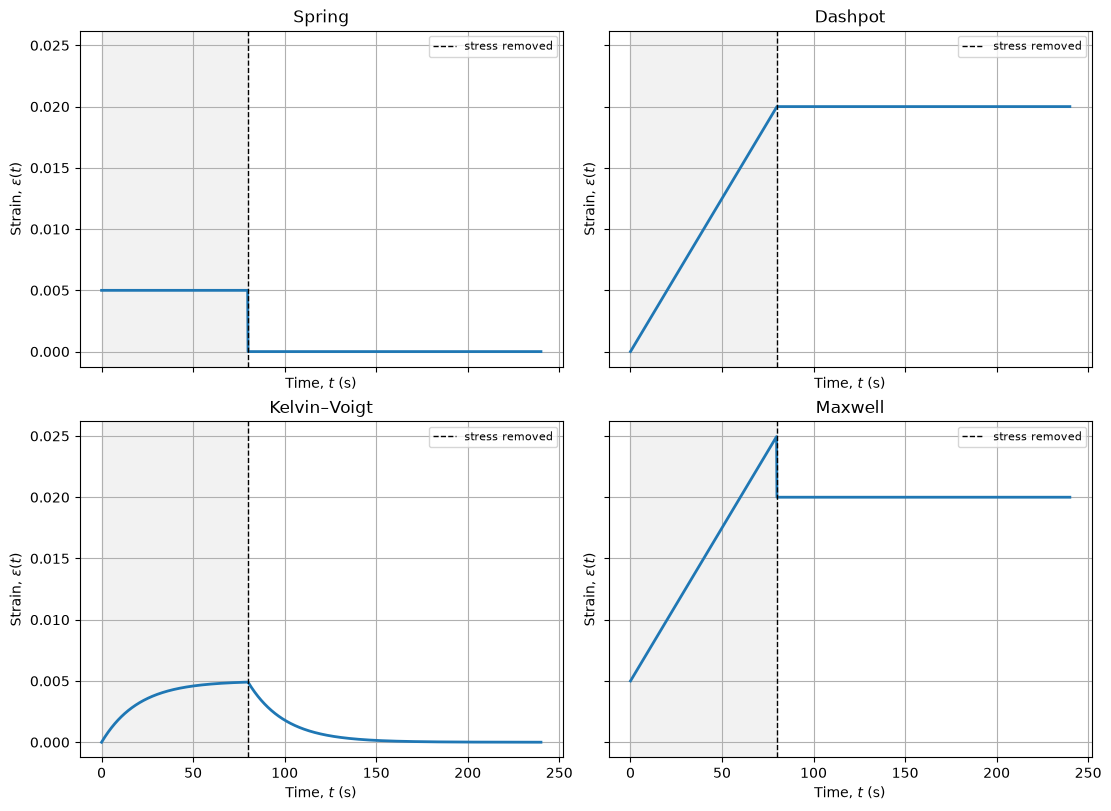

In [10]:
def creep_recovery_strain(t, sigma0, t_unload, compliance_function):
    t = np.asarray(t, dtype=float)
    strain = sigma0 * compliance_function(t)
    after_unloading = t >= t_unload
    strain[after_unloading] -= sigma0 * compliance_function(
        t[after_unloading] - t_unload
    )
    return strain

t_history = np.linspace(0.0, 240.0, 1201)
sigma0 = 1.0      # MPa
t_unload = 80.0   # s

recovery_models = {
    "Spring": lambda time: J_spring(time, E),
    "Dashpot": lambda time: J_dashpot(time, eta),
    "Kelvin–Voigt": lambda time: J_kelvin_voigt(time, E, eta),
    "Maxwell": lambda time: J_maxwell(time, E, eta),
}

fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True, sharey=True,
                         constrained_layout=True)

for ax, (name, compliance_function) in zip(axes.flat, recovery_models.items()):
    strain = creep_recovery_strain(
        t_history, sigma0, t_unload, compliance_function
    )
    ax.plot(t_history, strain, linewidth=2)
    ax.axvline(t_unload, color="black", linestyle="--", linewidth=1,
               label="stress removed")
    ax.axvspan(0.0, t_unload, color="gray", alpha=0.10)
    ax.set_title(name)
    ax.set_xlabel(r"Time, $t$ (s)")
    ax.set_ylabel(r"Strain, $\epsilon(t)$")
    ax.legend(fontsize=8)

plt.show()


## 1.7 Interpretation, checks, and laboratory deliverable

A fitted curve is physically acceptable only if its parameters and limiting behavior are acceptable. Check that

$$
J(0^+)=J_0,\qquad
J(\infty)=J_\infty,\qquad
\frac{\mathrm dJ}{\mathrm dt}\geq 0.
$$

Also inspect residuals. A systematic residual pattern indicates that the chosen model class is missing a timescale or a deformation mechanism. A low RMSE does not override physically inadmissible parameters or incorrect limiting behavior.

### Required analysis

1. Predict how $E$ and $\eta$ affect the four ideal compliance curves, then verify the prediction computationally.
2. Fit the SLS dataset and report $J_0$, $J_\infty$, $\tau_c$, $E_0$, and $E_\infty$ with units.
3. Rank the five candidate models using $\Delta\mathrm{AIC}$ and residual structure. Explain the physical reason for the preferred model.
4. Remove all observations with $t<10$ s and refit. Identify which parameter loses the most precision.
5. Interpret the residual strain after unloading for the dashpot and Maxwell models.
6. Add the fitted SLS model to the creep-recovery calculation and determine whether it recovers completely.

### Submission

Submit the completed notebook and a concise conclusion containing: the selected model, fitted parameters with units, one residual-based validation statement, one limiting-behavior check, and one experimental limitation of the ideal step-stress assumption.

The next notebook applies the complementary step-strain protocol and measures stress relaxation rather than creep.
